# Predicting lung cancer disease using Machine Learning

Accuracy: 0.9677, Precision: 0.9833, Recall: 0.9833, F1 Score: 0.9833


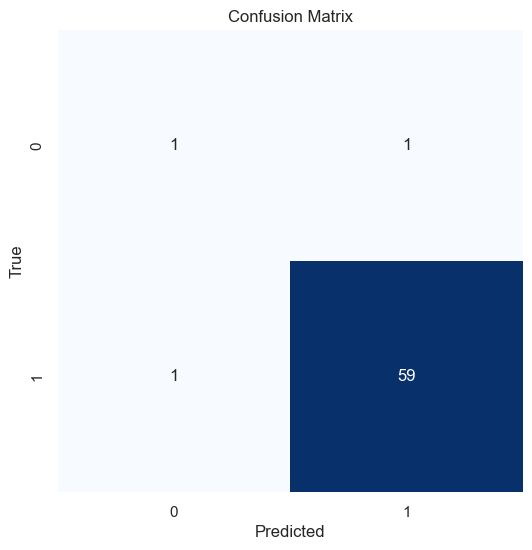

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset (assuming you have a CSV file)
data = pd.read_csv('lung_cancer.csv')

# Assuming the target column is 'LUNG_CANCER'
X = data.drop('LUNG_CANCER', axis=1)
y = data['LUNG_CANCER']

# Identify categorical columns
categorical_cols = [col for col in X.columns if X[col].dtype == 'O']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Create transformers for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor to apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model with the preprocessor
logistic_regression = LogisticRegression(max_iter=1000)
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', logistic_regression)])

# Train the model
model.fit(X_train, y_train)

# Save the trained model
joblib.dump(model, 'lung_cancer_model.sav')

# Load the model during prediction
loaded_model = joblib.load('lung_cancer_model.sav')

# Make predictions using the loaded model
y_pred = loaded_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='YES')
recall = recall_score(y_test, y_pred, pos_label='YES')
f1 = f1_score(y_test, y_pred, pos_label='YES')

print(f'Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

# Plot confusion matrix using Seaborn
plt.figure(figsize=(6, 6))
sns.set(style='whitegrid')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [12]:

# Create an SVM classifier
svm_classifier = SVC(kernel='linear', C=1)

# Bagging with SVM (using estimator instead of base_estimator)
bagging_svm = BaggingClassifier(estimator=svm_classifier, n_estimators=10, random_state=42)
bagging_svm.fit(X_train, y_train)
bagging_svm_predictions = bagging_svm.predict(X_test)
bagging_svm_accuracy = accuracy_score(y_test, bagging_svm_predictions)

print("Bagging SVM Accuracy:", bagging_svm_accuracy)

# AdaBoost with SVM (using estimator instead of base_estimator)
adaboost_svm = AdaBoostClassifier(estimator=svm_classifier, n_estimators=50, random_state=42, algorithm='SAMME')
adaboost_svm.fit(X_train, y_train)
adaboost_svm_predictions = adaboost_svm.predict(X_test)
adaboost_svm_accuracy = accuracy_score(y_test, adaboost_svm_predictions)

print("AdaBoost SVM Accuracy:", adaboost_svm_accuracy)

NameError: name 'SVC' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import seaborn as sns

### Importing the dataset

### Shape of the dataset (Rows, Columns)

In [ ]:
data.info

<bound method DataFrame.info of     GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1    

### Head of the dataset

In [ ]:
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
X.columns.to_list()

['GENDER',
 'AGE',
 'SMOKING',
 'YELLOW_FINGERS',
 'ANXIETY',
 'PEER_PRESSURE',
 'CHRONIC DISEASE',
 'FATIGUE ',
 'ALLERGY ',
 'WHEEZING',
 'ALCOHOL CONSUMING',
 'COUGHING',
 'SHORTNESS OF BREATH',
 'SWALLOWING DIFFICULTY',
 'CHEST PAIN']

<br><br>
# Exploratory Data analysis
<br>

### Renaming columns

In [ ]:
df.rename(columns ={'age':'Age','sex':'Sex','cp':'Chest_pain','trestbps':'Resting_blood_pressure','chol':'Cholesterol','fbs':'Fasting_blood_sugar',
                    'restecg':'ECG_results','thalach':'Maximum_heart_rate','exang':'Exercise_induced_angina','oldpeak':'ST_depression','slope':'ST_slope','ca':'Major_vessels',
                   'thal':'Thalassemia_types','target':'Heart_disease'}, inplace = True)

In [ ]:
# View of the Renamed Dataframe
df.head()

### Information about the data

In [ ]:
list(df.columns.values)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

### Description about the dataset

In [ ]:
df.describe()

### Are there any missing values?

In [ ]:
df.isna().sum() 

### Correlation matrix & Matrix Visualisation

In [ ]:
df.corr()

In [ ]:
# Let's make our correlation matrix visual
corr_matrix=df.corr()
fig,ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,
               annot=True,
               linewidths=0.5,
               fmt=".2f"
              )

In [ ]:
X=df.drop(['Outcome'],axis=1)
y=df['Outcome']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 1: Create individual SVM classifiers
svm1 = SVC(kernel='linear', C=1)
svm2 = SVC(kernel='rbf', C=1, gamma=0.1)
svm3 = SVC(kernel='poly', C=1, degree=2)

# Step 2: Hyperparameter tuning using GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best SVM model from hyperparameter tuning
best_svm = grid_search.best_estimator_

# Step 3: Create a VotingClassifier ensemble
ensemble = VotingClassifier(estimators=[
    ('svm1', svm1),
    ('svm2', svm2),
    ('svm3', svm3),
    ('best_svm', best_svm)
], voting='hard')  # You can choose 'hard' or 'soft' voting

# Train the ensemble model
ensemble.fit(X_train, y_train)

# Step 4: Make predictions and evaluate accuracy
y_pred = ensemble.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Ensemble Accuracy:", accuracy)
